Sprawozdanie: Klasyfikacja obrazów zbioru CIFAR-10 za pomocą sieci MLP - Michał Gryc

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F 
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


Na samym początku należy wczytać wszystkie biblioteki, które będą wykorzystywane w dalszej części zadania. 
Spis bibliotek:
- torch - najważniejsza biblioteka, z której bierze się komendy potrzebne do obsługi modelu MLP (Multilayer Perceptron)
- torchvision - z tego miejsca użytkownik pobiera bazę danych (zbiór obrazów CIFAR-10)
- seaborn - biblioteka potrzeba do generowania heatmapy, niezbędna przy czytelnej wizualizacji 
- matplotlib - służy do wizualizacji danych za pomocą wykresów
- numpy - biblioteka do działać matematycznych
- sklearn.metrics - służy do tworzenia macierzy (w przypadku tego zadania do macierzy pomyłek)


In [2]:
# Zmiana pikseli obrazow z zakresu 0-255 do 0-1 oraz formatu HWC na CHW (Channels, Height, Width)
transform = transforms.ToTensor()  
train_set = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_set = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
classes = train_set.classes
print("Train data ", len(train_set))
print("Test data: ", len(test_set))

c:\Users\Michał\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train data  50000
Test data:  10000


Następnie należy wczytać szukaną baze danych z biblioteki torchvision, oraz zmienić format zdjeć w naszej bazie danych. Związku z tym, że dane w datesets są zamisane za pomocą pikseli o wartościach 0-255 oraz formacie HWC - (Height, Width, Channels), a model tworzony na pomocą biblioteki torch wymaga innego rodzaju danych należy przekonwertować dane. Taką transformację danych można osiągnąć używając komendy transforms.ToTensor(), która zmienia piksele na wartości 0-1 i format na (Channels, Height, Width).

Po załadowaniu danych można zobaczyć ilość elementów w zbiorach.

In [3]:
def analyze_dataset(dataset):
    print("--- Statystyki zbioru ---")
    # 1. Wymiary i zakres
    img, label = dataset[0]
    print(f"Wymiary pojedynczego obrazu: {img.shape}")
    print(f"Minimalna wartość piksela: {img.min():.4f}")
    print(f"Maksymalna wartość piksela: {img.max():.4f}")
    
    # 2. Rozkład klas
    labels = [label for _, label in dataset]
    class_counts = np.bincount(labels)
    for i, count in enumerate(class_counts):
        print(f"Klasa {classes[i]}: {count} obrazów")

analyze_dataset(train_set)

--- Statystyki zbioru ---
Wymiary pojedynczego obrazu: torch.Size([3, 32, 32])
Minimalna wartość piksela: 0.0000
Maksymalna wartość piksela: 1.0000
Klasa airplane: 5000 obrazów
Klasa automobile: 5000 obrazów
Klasa bird: 5000 obrazów
Klasa cat: 5000 obrazów
Klasa deer: 5000 obrazów
Klasa dog: 5000 obrazów
Klasa frog: 5000 obrazów
Klasa horse: 5000 obrazów
Klasa ship: 5000 obrazów
Klasa truck: 5000 obrazów


W tym kawałku kodu definiowana jest funkcja analizy danych dla zbioru "trainnig set". Polega ona na wyświetleniu podstawowych danych o zbiorze, takich jak:
- wymiary pojedynczego obrazu 
- mnimalna wartość piksela
- maksymalna wartość piksela
- liczba obrazów w poszczególnej klasie

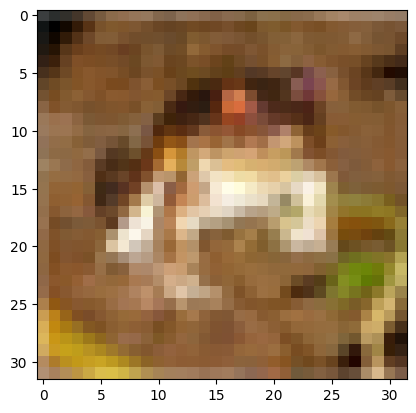

In [4]:
image, label = train_set[0]
plt.imshow(image.permute(1, 2, 0))
plt.show()

Ten fragment kodu odpowiada za przedstawioenie pojedynczego obrazu z bazy danych - (w tym przypadku jest to pierwszy rekord z train_set), aby go wyświetlić należy zmienić format zapisu obrazu aby biblioteka matplotlib mogła go odczytać

In [9]:
class MLP(nn.Module):
    def __init__(self, input_size = 32*32*3, hidden1=128, output_size=10, dropout_p=0.00):
        super(MLP, self).__init__()    
        self.fc1 = nn.Linear(input_size, hidden1) # pierwsza warstwa ukryta
        self.fc2 = nn.Linear(hidden1, hidden1//2)         # druga wartsta ukryta
        self.fc3 = nn.Linear(hidden1//2, output_size) # wyjście
        self.dropout = nn.Dropout(p=dropout_p) # Dodany dropout

    def forward(self, X):
        X = X.view(X.size(0), -1) # Spłaszczanie obrazu do 1D
        X = F.relu(self.fc1(X))
        X = self.dropout(X)
        X = F.relu(self.fc2(X))
        X = self.dropout(X)
        X = self.fc3(X)

        return F.log_softmax(X, dim=1) # dim=1 oznacza, że prawdopodobieństwa mają sumować się do 1

Zaimplementowano sieć MLP o następującej strukturze:

- Warstwa wejściowa: 3072 neurony.

- Warstwa ukryta 1: 128 neuronów z funkcją aktywacji ReLU i warstwą Dropout.

- Warstwa ukryta 2: 64 neurony z funkcją aktywacji ReLU i warstwą Dropout.

- Warstwa wyjściowa: 10 neuronów (odpowiadających klasom) z funkcją LogSoftmax.

Funkcja init definiuje przechodzenie pomiędzy warstwami - ucinając za każdym razem ilość parametrów na wejściu każego poziomu.

W funkcji forward używa X.view(X.size(0), -1), co zamienia obrazek 3D (3 kanały x 32 x 32) na wektor 1D o długości 3072, ponieważ warstwy typu Linear nie potrafią przetwarzać danych przestrzennych bezpośrednio. Tłumaczy ona jak dane mają się poruszać pomiędzy warstwami.


In [6]:
# Testowanie napisanego modelu na losowo wygranych danych
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False)
def train_model(model, train_loader, criterion, optimizer, epochs=5):
    # Przełączenie modelu w tryb uczenia
    model.train() 

    # Słownik do przechowywania historii wyników dla wykresów
    history = {'loss': [], 'acc': []}

    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        
        # Pętla po paczkach danych (batches)
        for images, labels in train_loader:
            
            optimizer.zero_grad() # 1. Zerowanie gradientów optymalizatora
            
            outputs = model(images) # 2. Forward pass: obliczenie przewidywań modelu
            
            loss = criterion(outputs, labels) # 3. Obliczenie funkcji straty (jak bardzo model się pomylił)
            
            loss.backward()  # 4. Backward pass: obliczenie gradientów (wsteczna propagacja błędu)
            
            optimizer.step() # 5. Aktualizacja modelu
            
            running_loss += loss.item() # 6. Liczenie błędów
            
            # Klasa z najwyższym prawdopodobieństwem
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
        # Średnia strata i dokładność dla całej epoki
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100. * correct / total
        
        # Zapis do historii
        history['loss'].append(epoch_loss)
        history['acc'].append(epoch_acc)
        print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%")

    return history

W tym kroku dane są dzielone na klasy o mniejszej ilości danych z wymieszanymi danymi (batch_size=64, shuffle=True), aby etap trenować trwał krócej. 

Po czym definiowana jest funkcja, która przełącza model w tryb uczenia (model.train()) oraz składa się z Epok (pełnych przejść przez cały zbiór danych), a każda epoka składa się z serii kroków optymalizacyjnych dla każdej paczki danych:

- optimizer.zero_grad() - Czyszczenie pamięci o błędach z poprzedniej paczki
- outputs = model(images) - Przekazuje obrazy przez sieć. Model wykonuje obliczenia na swoich aktualnych wagach i zwraca przewidywania (prawdopodobieństwa dla 10 klas).
- loss = criterion(outputs, labels) - Obliczanie funkcji straty. Sprawdzanie jak bardzo przewidywania modelu różnią się od prawdziwych etykiet (labels)
- loss.backward() - Komenda oblicza, jak bardzo każda waga w modelu przyczyniła się do popełnionego błędu.
- optimizer.step() - Na podstawie obliczonych w poprzednim kroku błędów, optymalizator (np. Adam) aktualizuje wagi w sieci, aby przy następnej próbie błąd był mniejszy.
- running_loss - Sumuje stratę z każdej paczki, aby po całej epoce wyliczyć średnią.
- outputs.max(1) - Wybiera klasę, której model jest najbardziej pewny.

Na samym końcu funkcja zapisuje wysztkie wyniki do historii i na wyjściu zwraca całą tą historię, aby było można następnie łatwo przedstawić te wyniki za pomocą wykresów

In [ ]:
def series_1():
    results_lr = {} # Wyniki z każdego testu
    learning_rates = [0.01, 0.001, 0.0001]  # Lista wartości "Learning Rate" do przetestowania
    train_loader = DataLoader(train_set, batch_size=64, shuffle=True)

    # Funkcja straty
    criterion = nn.CrossEntropyLoss()
    # Testowanie kolejnych wartość learning_rates
    for i in learning_rates:
        print(f"\n--- Eksperyment dla LR = {i} ---")
        new_model = MLP() 
        optimizer = torch.optim.Adam(new_model.parameters(), lr=i)
        
        history = train_model(new_model, train_loader, criterion, optimizer, epochs=5)
        
        results_lr[i] = history

    # Tworzenie okna dla wykresu
    plt.figure(figsize=(10, 5))

    # Pętla z wyników
    for lr, hist in results_lr.items():
        # Rysowanie linii dla konkretnych wyników.
        plt.plot(hist['acc'], label=f'LR = {lr}')

    plt.title('Wpływ Learning Rate na Accuracy w kolejnych epokach')
    plt.xlabel('Epoka (od 0 do 4)')
    plt.ylabel('Dokładność (Accuracy %)')
    plt.legend()
    plt.show()

Głównym celem tej funkcji jest zbadanie, jak szybkość uczenia się (Learning Rate) wpływa na to, jak skutecznie i stabilnie sieć neuronowa MLP uczy się rozpoznawać obrazy.

Funkcja tworzy:
- results_lr = {} - pusty słownik przygotowywany do przechowywania wyników
- learning_rates = [0.01, 0.001, 0.0001] - wartości uczenia się, które funkcja będzie sprawdzać
- criterion = nn.CrossEntropyLoss() - definiowanie funkcji straty, która będzie identyczna dla wszystkich trzech testów, aby porównanie było rzetelne.

Następnie program przechodzi przez pętle, która będzie przeprowadzać eksperyment:
- new_model = MLP() - tworzy nowy model MLP, który będzie szkolić 
- optimizer = ... - optymalizator "Adam"
- history - zmienna wywołuje funkcję treningową na 5 epok, która zwraca historię wyników zapisaną w zmiennej history
- results_lr[i] = history - zapisanie wyników z pętli do słownika z wynikami

Na sam koniec funkcja wyświetla wyniki na wykresie generowanym za pomocą matplotliba. Wyniki przedstawiono na zrzucie ekranu poniżej. 
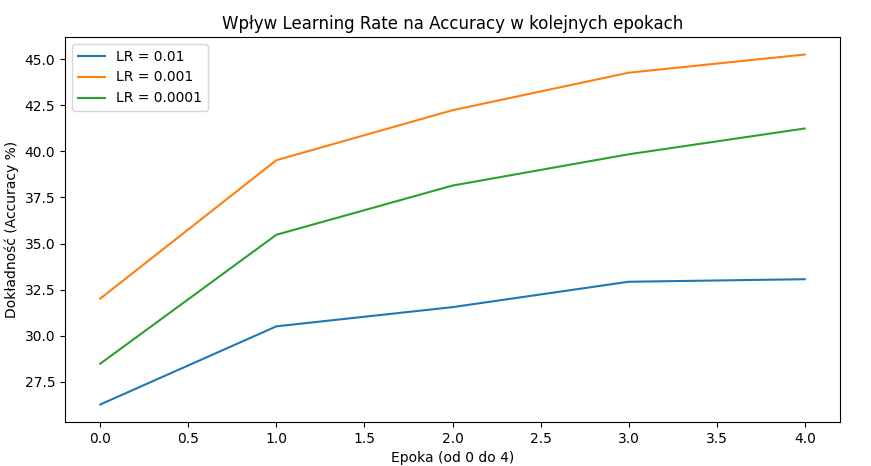

Wnioski:

Im mniejsza wartość szybkiego uczenia tym model jest bardziej poprawny. Jednakże warto zauważyć, że nawet najlepszy model oscyluje wokół 45 dokładności. Potwierdza to ograniczenia sieci w pełni połączonych (MLP) w przetwarzaniu danych obrazowych – brak warstw konwolucyjnych (CNN) uniemożliwia modelowi zrozumienie przestrzennych zależności w obrazie (np. kształtów), co narzuca "szklany sufit" na końcowy wynik accuracy.

Wybór LR = 0.001 stanowi najlepszy kompromis między szybkością zbieżności a końcową precyzją modelu. Wartość ta została wybrana jako parametr bazowy do dalszych testów (zmienny Batch Size oraz Dropout) w celu poszukiwania dalszych usprawnień.

In [ ]:
def series_2():
    results_batch = {}
    batch_sizes = [16, 32, 64, 128]  # Lista wartości "Batch Sizes" do przetestowania   

    # Funkcja straty
    criterion = nn.CrossEntropyLoss()

    # Testowanie kolejnych wartość Batch Sizes
    for i in batch_sizes:
        print(f"\n--- Eksperyment dla Batch Size = {i} ---")
        current_train_loader = DataLoader(train_set, batch_size=i, shuffle=True)
        new_model = MLP() 
        optimizer = torch.optim.Adam(new_model.parameters(), lr=0.0001)
        
        history = train_model(new_model, current_train_loader, criterion, optimizer, epochs=5)
        
        results_batch[i] = history

    # Tworzenie okna dla wykresu
    plt.figure(figsize=(12, 6))

    # Pętla z wyników
    for bs, hist in results_batch.items():
        # Rysowanie linii dla konkretnych wyników.
        plt.plot(hist['acc'], label=f'Batch Size = {bs}')

    plt.title('Wpływ Batch Size na Accuracy (CIFAR-10)')
    plt.xlabel('Epoka')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)
    plt.show()

Tutaj należy zauważyć, że funkcja jest definiowana w taki sam sposób. Różnica jest taka że model zostaje sprawdzany, tym razem dla innych wielkości klas. 

Funkcja tworzy:
- results_batch = {} - pusty słownik przygotowywany do przechowywania wyników
- batch_sizes = [16, 32, 64, 128] - wielkości danych w klasach, które funkcja będzie sprawdzać
- criterion = nn.CrossEntropyLoss() - definiowanie funkcji straty, która będzie identyczna dla wszystkich trzech testów, aby porównanie było rzetelne.

Następnie program przechodzi przez pętle, która będzie przeprowadzać eksperyment:
- new_model = MLP() - tworzy nowy model MLP, który będzie szkolić 
- current_train_loader = DataLoader(train_set, batch_size=i, shuffle=True) - dla każdej wartości w batches_sizes pętla tworzy nowy zestaw danych
- optimizer = ... - optymalizator "Adam"
- history - zmienna wywołuje funkcję treningową na 5 epok, która zwraca historię wyników zapisaną w zmiennej history
- results_batch[i] = history - zapisanie wyników z pętli do słownika z wynikami

Wyniki eksperymentów przedstawiono na zrzucie ekranu poniżej:

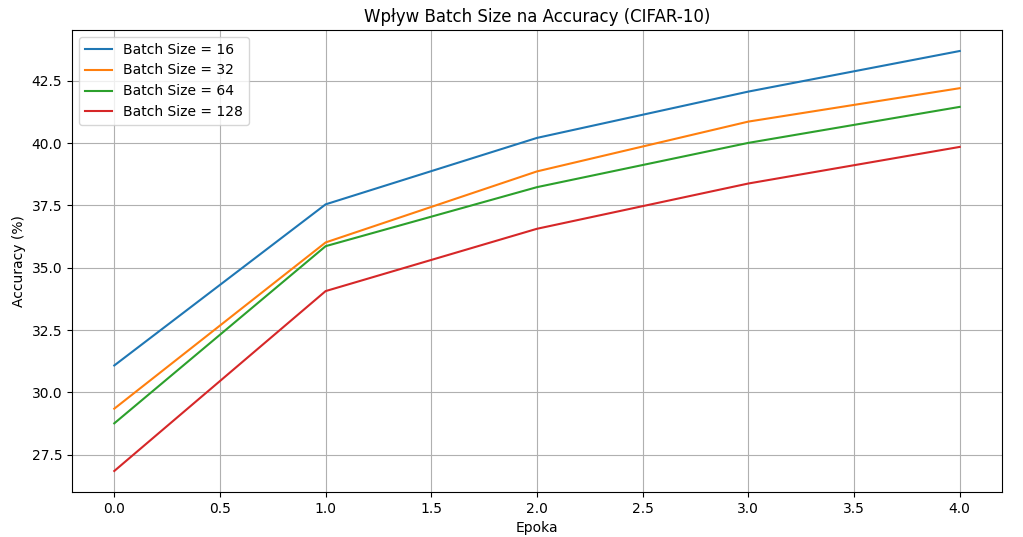


Wnioski:

Z wykresu przedstawionego powyżej wyraźnie widać, że im mniejsza wielkość klas tym model jest dokładniejszy. Wydaje się to dość logiczne, gdyż im mniej danych model ma danych do naucznia się przy małej ilości prób tym łatwiej jest mu się wyszkolić i ma mniejsze ryzyko błędu.

Warto zaznaczyć, że przy bardzo dużych zbiorach danych zazwyczaj wybiera się wartości pośrednie (np. 32 lub 64), aby zachować balans między szybkością obliczeń a tempem nauki. Związku z tym do dalszych eksperymentów wybrano batch = 64.


In [8]:
def series_3():
    results_dropout = {}
    dropout_values = [0.0, 0.3, 0.5]  #  Lista wartości "Dropout" do przetestowania
    train_loader = DataLoader(train_set, batch_size=64, shuffle=True)

    # Funkcja straty
    criterion = nn.CrossEntropyLoss()

    # Testowanie kolejnych wartość Dropoutu
    for i in dropout_values:
        print(f"\n--- Ekseryment dla Dropout = {i} ---")
        new_model = MLP(dropout_p=i)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(new_model.parameters(), lr=0.0001)
        
        history = train_model(new_model, train_loader, criterion, optimizer, epochs=10)
        
        results_dropout[i] = history

    # Tworzenie okna dla wykresu
    plt.figure(figsize=(12, 6))

    # Pętla z wyników
    for drp, hist in results_dropout.items():
        # Rysowanie linii dokładności dla każdej wartości dropoutu
        plt.plot(hist['acc'], label=f'Dropout = {drp}')

    plt.title('Wpływ Dropout na Accuracy (CIFAR-10)')
    plt.xlabel('Epoka')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)
    plt.show()

Podobnie jak w eksperymentach powyżej posłużono się tym samym schematem definiowania funkcji.

Funkcja tworzy:
- results_dropout = {} - pusty słownik przygotowywany do przechowywania wyników
- dropout_values = [0.0, 0.3, 0.5] - wielkości dropoutu, które funkcja będzie sprawdzać
- criterion = nn.CrossEntropyLoss() - definiowanie funkcji straty, która będzie identyczna dla wszystkich trzech testów, aby porównanie było rzetelne.

Następnie program przechodzi przez pętle, która będzie przeprowadzać eksperyment:
- new_model = MLP(dropout_p=i) - tworzy nowy model MLP z konkretna wartością dropoutu, który będzie szkolony
- optimizer = ... - optymalizator "Adam"
- history - zmienna wywołuje funkcję treningową na 5 epok, która zwraca historię wyników zapisaną w zmiennej history
- results_dropout[i] = history - zapisanie wyników z pętli do słownika z wynikami

Wyniki eksperymentów przedstawiono na zrzucie ekranu poniżej:

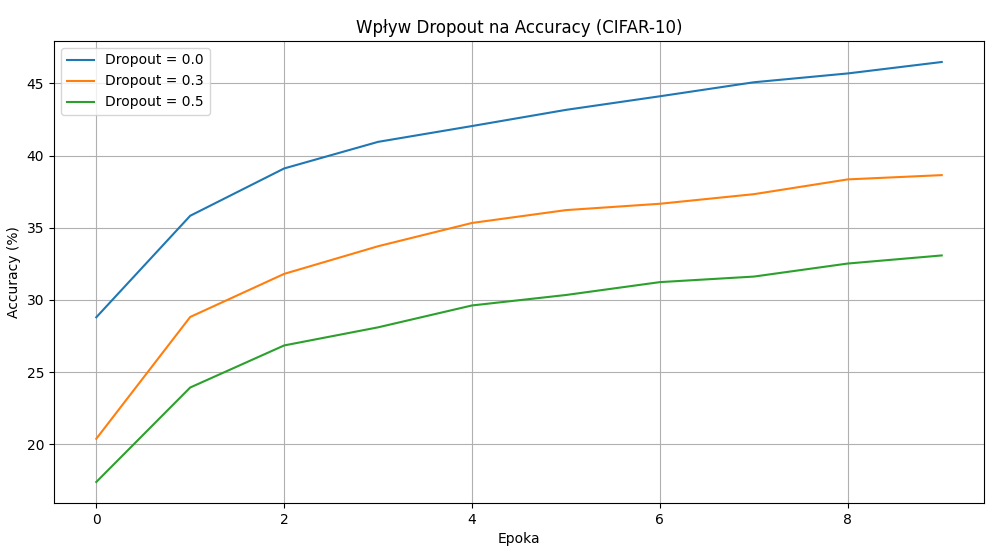

Wnioski:

- Model bez dropoutu zazwyczaj wykazuje najszybszy wzrost dokładności na danych treningowych w pierwszych epokach.
    Jest to jednak rozwiązanie ryzykowne; przy prostych sieciach MLP i trudnym zbiorze jak CIFAR-10, model może zacząć zapamiętywać obrazy treningowe (overfitting), co skutkuje brakiem postępów lub spadkiem dokładności na zbiorze testowym w późniejszych fazach.

- Umiarkowany Dropout p=0.3
    Krzywa uczenia dla tej wartości jest zazwyczaj najstabilniejsza – ma mniej gwałtownych skoków, co świadczy o lepszej generalizacji modelu. Związku z tym ten parametr wybrano do finalnego modelu.

- Wysoki Dropout p=0.5
    Dokładność po 10 epokach może być niższa niż w przypadku mniejszych wartości dropoutu, ponieważ sieć ma ograniczoną "pojemność" do zapamiętywania wzorców w każdym kroku. Taka wartość może być jednak korzystna przy bardzo długim treningu (np. 50-100 epok). Jednakże taka wartość jest mało praktyczna, gdyż modele nie będą testowane na tak dużej ilości epok.

In [ ]:
def series_4():
    results_neurons = {}
    neuron_configs = [64, 128, 256]  # Lista wartości "liczby neuronów " do przetestowania
    train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
    criterion = nn.CrossEntropyLoss()

    for n in neuron_configs:
        print(f"\n--- Eksperyment dla liczby neuronów = {n} ---")
        new_model = MLP(hidden1=n)
        optimizer = torch.optim.Adam(new_model.parameters(), lr=0.0001)
        
        history = train_model(new_model, train_loader, criterion, optimizer, epochs=10)
        
        results_neurons[n] = history

     # Tworzenie okna dla wykresu
    plt.figure(figsize=(12, 6))

    # Pętla z wyników
    for n, hist in results_neurons.items():
        # Rysowanie linii dokładności dla każdej wartości liczby neuronów
        plt.plot(hist['acc'], label=f'{n} neuronów')

    plt.title('Wpływ liczby neuronów na Accuracy (CIFAR-10)')
    plt.xlabel('Epoka')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)
    plt.show()

Ostatni eksperyment polega na sprawdzeniu wpływie liczby neuronów w warstwach w modelu MLP na dokładność szkolonego modelu

Funkcja tworzy:
- results_neurons = {}- pusty słownik przygotowywany do przechowywania wyników
- neuron_configs = [64, 128, 256] - liczba neurownów w pierwszej warstwie ukrytej, które funkcja będzie sprawdzać
- criterion = nn.CrossEntropyLoss() - definiowanie funkcji straty, która będzie identyczna dla wszystkich trzech testów, aby porównanie było rzetelne.

Następnie program przechodzi przez pętle, która będzie przeprowadzać eksperyment:
- new_model = MLP(hidden1=n) - tworzy nowy model MLP z konkretna liczbą neurnów, który będzie szkolony
- optimizer = ... - optymalizator "Adam"
- history - zmienna wywołuje funkcję treningową na 5 epok, która zwraca historię wyników zapisaną w zmiennej history
- results_neurons[n] = history - zapisanie wyników z pętli do słownika z wynikami

Wyniki eksperymentów przedstawiono na zrzucie ekranu poniżej:

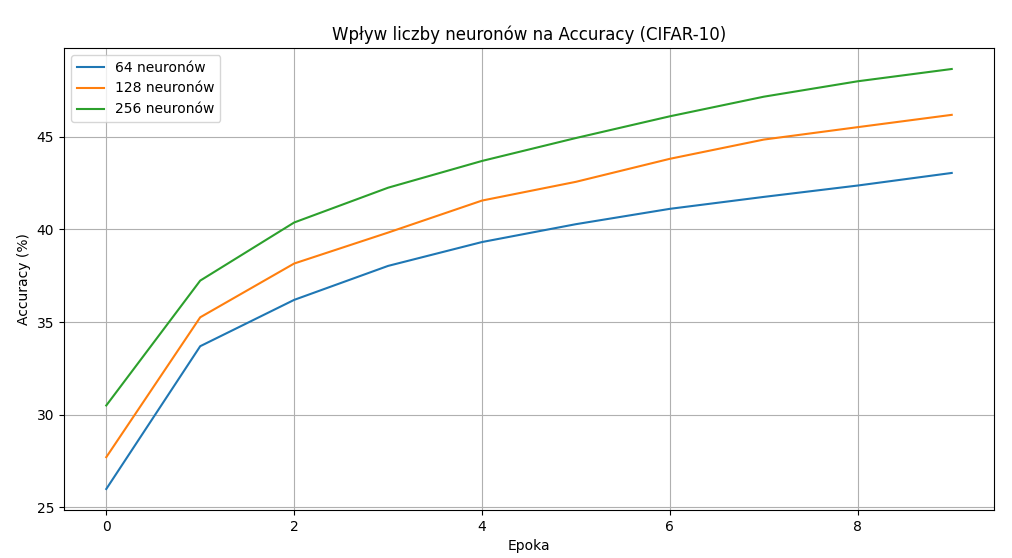


Wnioski:

Z przedstawionych wykresów powyżej wyraźnie widać, iż zwiększenie liczby połączneń neuronalnych w pierwszej warstwie ukrytej pozytywnie wpływa na dokładność szkolonego modelu, ale wiąże się z większym kosztem obliczeniowym i ryzykiem przeuczenia (overfittingu). 

Warto również podkreślić, że wynik na poziomie 48% dla 256 neuronów jest bardzo solidny jak na prosty perceptron wielowarstwowy operujący na surowych pikselach CIFAR-10. Dlatego, więc wybrano ten parametr do szkolenia najlepszego modelu MLP.


In [10]:
def final_model():
    final_model = MLP(hidden1=256, dropout_p=0.3)
    optimizer = torch.optim.Adam(final_model.parameters(), lr=0.0001)
    train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
    criterion = nn.CrossEntropyLoss()

    print("Trenowanie finałowego modelu do metryk...")
    train_model(final_model, train_loader, criterion, optimizer, epochs=15)
    return final_model

Po zrealizowaniu wszystkich eksperymentów można przystąpić do definiowania najlepszego modelu. We wnioskach powyżej ustalono, że najlepszymi parametrami będą:
- learing_rate = 0.0001  - szybkość uczenia na poziomie 0,0001
- batch_size = 64  - wielkości danych w klasach równe 64
- dropout = 0.3  - wielkość dropoutu równa 0,3
- hidden_1 = 256  - liczba połączeń neuralnych w pierwszej warstwie ukrytej równa 256

Trenowanie finałowego modelu do metryk...
Epoch 1/15 - Loss: 2.0439, Accuracy: 24.99%
Epoch 2/15 - Loss: 1.8693, Accuracy: 32.64%
Epoch 3/15 - Loss: 1.8029, Accuracy: 35.31%
Epoch 4/15 - Loss: 1.7605, Accuracy: 37.20%
Epoch 5/15 - Loss: 1.7247, Accuracy: 38.37%
Epoch 6/15 - Loss: 1.6993, Accuracy: 39.66%
Epoch 7/15 - Loss: 1.6699, Accuracy: 40.72%
Epoch 8/15 - Loss: 1.6487, Accuracy: 41.52%
Epoch 9/15 - Loss: 1.6299, Accuracy: 41.99%
Epoch 10/15 - Loss: 1.6127, Accuracy: 42.97%
Epoch 11/15 - Loss: 1.6027, Accuracy: 43.19%
Epoch 12/15 - Loss: 1.5912, Accuracy: 43.91%
Epoch 13/15 - Loss: 1.5740, Accuracy: 44.36%
Epoch 14/15 - Loss: 1.5616, Accuracy: 44.53%
Epoch 15/15 - Loss: 1.5508, Accuracy: 45.01%
SZCZEGÓŁOWY RAPORT KLASYFIKACJI
              precision    recall  f1-score   support

    airplane       0.54      0.55      0.54      1000
  automobile       0.57      0.65      0.60      1000
        bird       0.35      0.29      0.31      1000
         cat       0.36      0.29      0.32

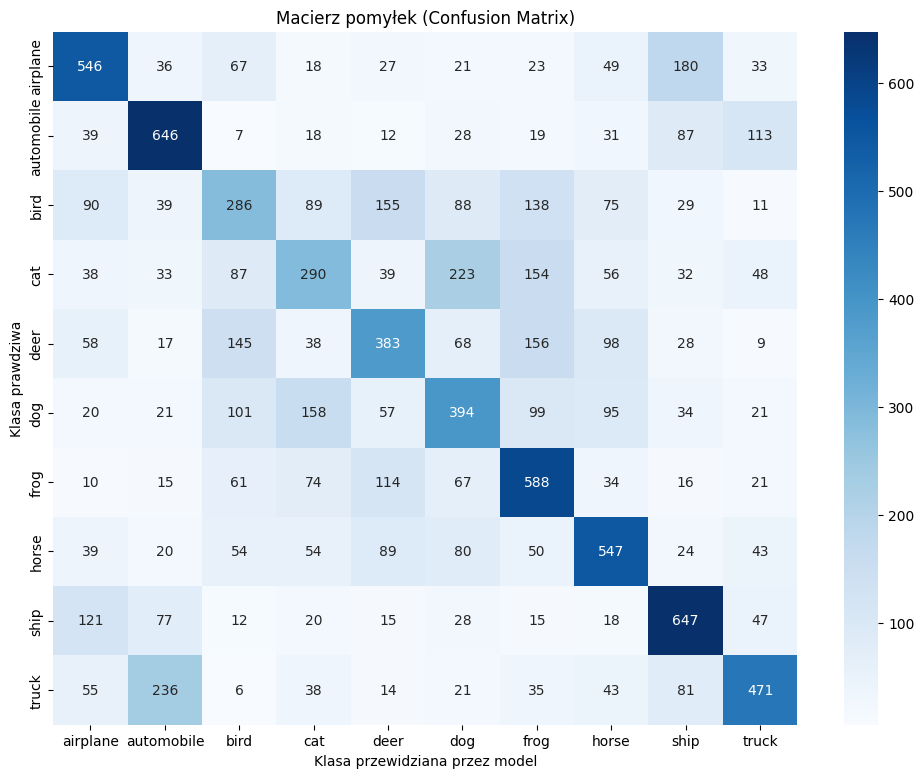

In [12]:
def run_final_metrics(model, test_loader, classes):
    # Ustawienie modelu w tryb testowy 
    model.eval()
    
    y_true = []
    y_pred = []
    
    # 2. Przewidywania modelu dla całego zbioru testowego
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = outputs.max(1)
            y_true.extend(labels.numpy())
            y_pred.extend(predicted.numpy())
    
    # Raport klasyfikacji - tabela z precyzją, czułością i F1
    print("SZCZEGÓŁOWY RAPORT KLASYFIKACJI")
    print(classification_report(y_true, y_pred, target_names=classes))
    
    # Macierz pomyłek - mapa ciepła
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 9))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.title('Macierz pomyłek (Confusion Matrix)')
    plt.ylabel('Klasa prawdziwa')
    plt.xlabel('Klasa przewidziana przez model')
    plt.show()
run_final_metrics(final_model(), test_loader, classes)

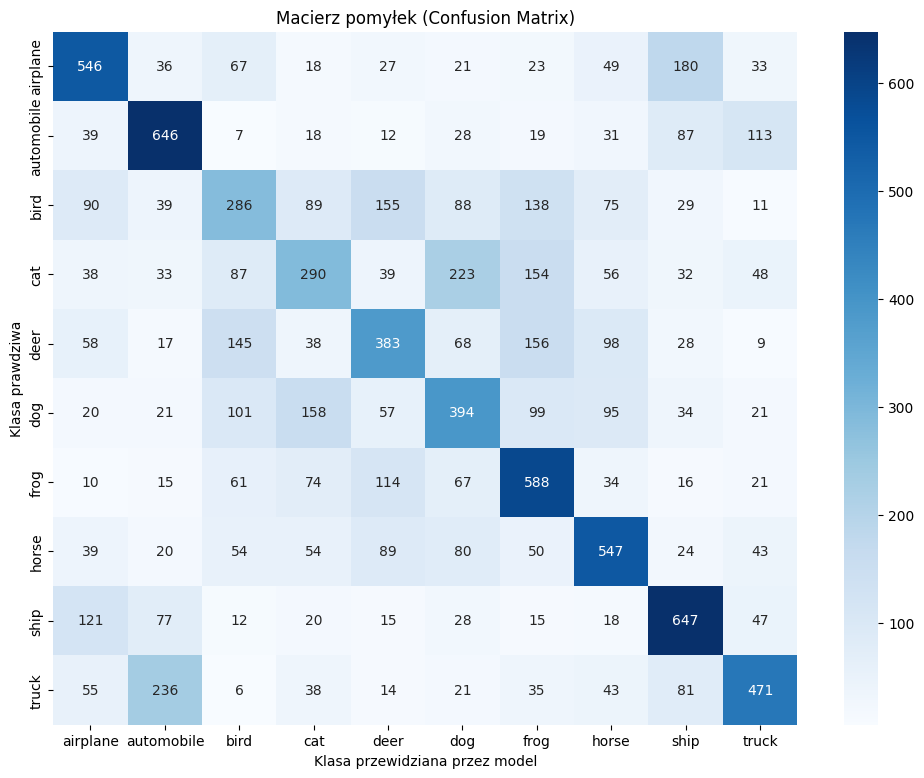

PODSUMOWANIE:

Model MLP jest beznadziejny do rozpoznawania obrazów. Nawet najlepiej dobrane parametry do modelu MLP nie dają dokładności powyżej 50%. Na testach przeprowadzonych powyżej model zatrzymał się na dokładności 45%. Jednakże można wyróznić dziedziny, w których model uzyskiwał gorsze i lepsze wyniki.

Najmocniejsza strony:
Sieć najlepiej poradziła sobie z rozpoznawaniem obiektów mechanicznych. Najwyższy wskaźnik F1-Score uzyskała klasa automobile (0.60) oraz airplane (0.54). Wynika to prawdopodobnie z faktu, że pojazdy te mają wyraźniejsze, zgeometryzowane kształty i często występują na jednolitym tle (niebo, asfalt).

Najsłabsze strony:
Model najczęściej zawodził w przypadku zwierząt. Najniższy F1-Score zanotowano dla klas bird (0.31) oraz cat (0.32). Zwierzęta na zdjęciach w zbiorze CIFAR-10 potrafią przyjmować różne pozy, ukrywać się w złożonym tle (np. trawa, drzewa) i charakteryzują się bardziej miękkimi liniami, co stanowi ogromne wyzwanie dla sieci gubiącej kontekst przestrzenny.

WERDYKT:

Aby jednak w przyszłości drastycznie poprawić wyniki klasyfikacji z poziomu ok. 50% na 80-90%, konieczna będzie zmiana architektury z klasycznego MLP na Konwolucyjne Sieci Neuronowe (CNN), które są dedykowanym standardem w dziedzinie Computer Vision.